<a href="https://colab.research.google.com/github/gulshan-katankar/language_modelling/blob/main/model_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [51]:
import requests

url = "https://raw.githubusercontent.com/gulshan-katankar/language_modelling/refs/heads/main/names.txt"

words = requests.get(url).text.splitlines()

In [52]:
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [53]:
len(words)

32033

In [54]:
#build the vocab of characters and mappings

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [55]:
# build the dataset

block_size = 3 # context length: how many characters do we tako to predict the next one?
x, y = [], []
for w in words [:5]:

  print(w)
  context = [0] * block_size #start with the padded context of 0
  for ch in w + '.': #iterate over all the char
    ix = stoi[ch]
    x. append(context) #stores the context
    y.append(ix) #stores the labels for the context
    print(''.join(itos[i] for i in context), ' -- >', itos[ix])
    context = context [1:] + [ix] # crop and append

x = torch.tensor(x)
y = torch.tensor(y)

emma
...  -- > e
..e  -- > m
.em  -- > m
emm  -- > a
mma  -- > .
olivia
...  -- > o
..o  -- > l
.ol  -- > i
oli  -- > v
liv  -- > i
ivi  -- > a
via  -- > .
ava
...  -- > a
..a  -- > v
.av  -- > a
ava  -- > .
isabella
...  -- > i
..i  -- > s
.is  -- > a
isa  -- > b
sab  -- > e
abe  -- > l
bel  -- > l
ell  -- > a
lla  -- > .
sophia
...  -- > s
..s  -- > o
.so  -- > p
sop  -- > h
oph  -- > i
phi  -- > a
hia  -- > .


/tmp/ipykernel_795/1879530691.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch. tensor(X)
/tmp/ipykernel_795/1879530691.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch. tensor(Y)


In [56]:
x.shape, x.dtype, y.shape, y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

from 5 words we have a dataset of 32 examples, where each neural net have an input of size 3 they are integers

the labels too are integers

In [57]:
x

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [58]:
y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [59]:
c = torch.randn((27,2)) #this is the embedding table, every char will have a 2 dim embedding

In [60]:
c #this is randomly generated as a model param, and will be optimized further

tensor([[-0.4943, -0.6001],
        [ 2.3422,  1.1927],
        [ 1.2912,  0.4738],
        [ 1.0135,  1.1603],
        [ 0.0553, -0.2859],
        [ 1.6316,  1.3174],
        [ 1.2597, -0.4281],
        [ 0.5101, -2.5140],
        [ 1.0768, -0.0260],
        [ 0.4749, -1.3028],
        [ 0.7013,  0.8025],
        [-1.2906,  1.9355],
        [ 1.0527, -1.6409],
        [-1.5479,  0.9190],
        [-0.1925, -0.4046],
        [ 0.0935, -1.6583],
        [ 0.7202, -1.5083],
        [-0.5653, -0.6547],
        [ 1.3229,  1.8455],
        [ 0.9772,  1.9161],
        [-0.1519, -0.8340],
        [-1.3176, -0.5086],
        [ 1.5867,  0.3746],
        [ 0.4975, -0.4255],
        [ 0.4376, -0.3920],
        [-0.3906,  0.6960],
        [-0.7864, -1.2403]])

so now we willgenerate embeddings for the x using the random embedding table we generated above

In [61]:
emb = c[x]
emb

tensor([[[-0.4943, -0.6001],
         [-0.4943, -0.6001],
         [-0.4943, -0.6001]],

        [[-0.4943, -0.6001],
         [-0.4943, -0.6001],
         [ 1.6316,  1.3174]],

        [[-0.4943, -0.6001],
         [ 1.6316,  1.3174],
         [-1.5479,  0.9190]],

        [[ 1.6316,  1.3174],
         [-1.5479,  0.9190],
         [-1.5479,  0.9190]],

        [[-1.5479,  0.9190],
         [-1.5479,  0.9190],
         [ 2.3422,  1.1927]],

        [[-0.4943, -0.6001],
         [-0.4943, -0.6001],
         [-0.4943, -0.6001]],

        [[-0.4943, -0.6001],
         [-0.4943, -0.6001],
         [ 0.0935, -1.6583]],

        [[-0.4943, -0.6001],
         [ 0.0935, -1.6583],
         [ 1.0527, -1.6409]],

        [[ 0.0935, -1.6583],
         [ 1.0527, -1.6409],
         [ 0.4749, -1.3028]],

        [[ 1.0527, -1.6409],
         [ 0.4749, -1.3028],
         [ 1.5867,  0.3746]],

        [[ 0.4749, -1.3028],
         [ 1.5867,  0.3746],
         [ 0.4749, -1.3028]],

        [[ 1.5867,  0

if you read the above embeddings carefully you can see pytorch assigned the same value the index have from the embedding table as well as the the mapping we did

for eg :

. . e -> [[ 1.2832, -0.5584],
         [ 1.2832, -0.5584],
         [-1.2772,  1.3232]],

here . has a 0 index in x and e has 5th index so the embeddings we got also have the same index value from the embeddings table c

In [62]:
emb.shape

torch.Size([32, 3, 2])

now we have the embeddings for all of the 32, 3 integers

In [63]:
w1 = torch.randn((6, 100)) #6 coz we have 3 input size and 2 dim, and 100 are the no of neurons
b1 = torch.randn(100)

**hidden layer calculation**

In [64]:
h = torch.tanh(emb.view(-1,6) @ w1 + b1) # -1 coz python will automatically interpret what should be the size here

In [65]:
h

tensor([[-0.8562, -0.9109, -0.4309,  ...,  0.9642, -0.9867, -0.9912],
        [ 0.9135,  1.0000,  0.9274,  ...,  0.9949,  0.9764,  0.1805],
        [ 0.7062,  0.8967,  0.7854,  ...,  0.9925, -0.9999, -0.5749],
        ...,
        [ 0.8758, -0.9837,  0.6732,  ...,  0.9807,  0.7121, -0.9981],
        [ 0.6039, -1.0000, -0.1451,  ...,  0.8900, -0.4726, -0.9989],
        [ 0.9881,  0.0837,  0.9256,  ...,  0.9938,  1.0000, -0.2214]])

In [66]:
h.shape

torch.Size([32, 100])

In [67]:
w2 = torch.randn((100, 27)) #the input now is 100 and the output would be 27 coz we have 27 char as the next possible output
b2 = torch.randn(27)

In [68]:
logits = h @ w2 + b2 # the output of the neural nets

In [69]:
logits

tensor([[-2.9164e+00, -1.3176e+01,  7.5983e+00, -5.5177e+00, -2.0656e-01,
         -2.1613e+01, -8.8806e+00, -5.7125e+00, -6.9663e-01,  7.1810e+00,
          6.5418e+00, -4.9478e+00,  5.0270e+00,  1.2260e+01,  3.8639e+00,
          1.4495e-01, -3.6671e+00,  3.9521e+00,  1.7663e+00,  6.5119e+00,
         -4.1228e+00,  5.1837e+00, -4.7234e+00,  1.6317e+01,  1.6800e+00,
         -3.0414e+00, -2.8084e+00],
        [ 1.0959e+01,  5.1757e+00,  8.5424e+00, -6.5097e+00, -2.3197e+00,
         -3.9813e+00,  3.2064e+00, -9.9126e+00, -5.7624e+00,  1.1958e+01,
         -1.2417e+01,  1.3894e+00, -1.1473e+01, -1.2113e+01, -7.3789e+00,
         -1.3619e+01, -1.4385e-01, -1.8752e+00, -4.4374e+00,  5.9443e+00,
          1.9389e+00, -4.8405e+00, -1.0928e+00,  8.6404e-01, -1.6939e+00,
         -1.2353e+01,  1.3727e+01],
        [ 8.3053e+00,  4.8578e-01,  2.4068e+00,  2.9215e+00, -1.2482e-01,
         -1.7858e+01,  3.3426e+00,  3.5749e+00, -2.9411e-02, -8.0803e+00,
          6.4495e+00,  7.4898e-01, -1.68

In [70]:
logits.shape

torch.Size([32, 27])

In [71]:
counts = logits.exp()

In [72]:
prob = counts / counts.sum(1, keepdims=True)

In [73]:
prob.shape

torch.Size([32, 27])

In [74]:
loss = -prob[torch.arange(32), y].log().mean()
loss

tensor(15.1861)

**clean version**

In [75]:
x.shape, y.shape

(torch.Size([32, 3]), torch.Size([32]))

In [76]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [77]:
sum(p.nelement() for p in parameters) #no of params in total

3481

In [78]:
emb = C[x] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 +b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdims=True)
# loss =- prob[torch.arange(32), y].log().mean()

#instead of that long calc we can just use the cross_entropy function
F.cross_entropy(logits, y)
loss

tensor(15.1861)

In [79]:
for p in parameters:
  p.requires_grad = True

In [81]:
for _ in range(1000):

  # forward pass
  emb = C[x] # (32, 3, 2)
  h = torch. tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, y)

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  for p in parameters:
    p.data += -0.1 * p.grad

print(loss.item())

0.25609633326530457


**IMPLEMENTING ON FULL DATASET**

In [130]:
# build the dataset

block_size = 3 # context length: how many characters do we tako to predict the next one?
x, y = [], []
for w in words:

  context = [0] * block_size #start with the padded context of 0
  for ch in w + '.': #iterate over all the char
    ix = stoi[ch]
    x. append(context) #stores the context
    y.append(ix) #stores the labels for the context
    context = context [1:] + [ix] # crop and append

x = torch.tensor(x)
y = torch.tensor(y)

In [131]:
x.shape, x.dtype, y.shape, y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [132]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [125]:
sum(p.nelement() for p in parameters) #no of params in total

3481

In [133]:
for p in parameters:
  p.requires_grad = True

we will also implement mini batch here, so what mini batch does is forms random batches of the training set and train the neural network on that batch only and it does this multiple times

to find the best learning rate we created numbers between -0.001 and -1

In [134]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [128]:
lri = []
lossi = []

for i in range(1000):

  #mini batch construct
  ix = torch.randint(0, x.shape[0], (32,)) #this will generate 32 random numbers between 0 and x.shape

  # forward pass
  emb = C[x[ix]] # (32, 3, 2)
  h = torch. tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, y[ix])
  print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = lrs[i]
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  lri.append(lre[i])
  lossi.append(loss.item())

16.29591178894043
19.318130493164062
20.78654670715332
20.243003845214844
23.676860809326172
17.555044174194336
16.31553840637207
19.195919036865234
20.133182525634766
18.630699157714844
16.672739028930664
18.787464141845703
20.89751625061035
19.172849655151367
20.809429168701172
17.496509552001953
20.764368057250977
19.871721267700195
20.238353729248047
17.372638702392578
18.31930160522461
18.694869995117188
18.828752517700195
18.0209903717041
16.05813980102539
18.33135414123535
15.03396987915039
18.984994888305664
18.56954002380371
17.696989059448242
17.270963668823242
18.186325073242188
22.9228572845459
21.73362159729004
16.001005172729492
20.544401168823242
19.933700561523438
17.564353942871094
17.599658966064453
19.680200576782227
18.487171173095703
17.034753799438477
18.90924835205078
17.941051483154297
19.04327392578125
16.74005699157715
21.82743263244629
20.162723541259766
17.304685592651367
19.487964630126953
17.464832305908203
15.428094863891602
16.32012939453125
21.373380661

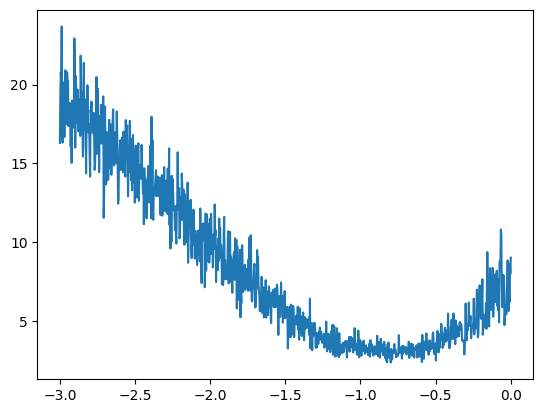

In [129]:
plt.plot(lri, lossi)

so we came to the conclusion that 0.1 is a good learning rate

In [139]:
lri = []
lossi = []

for i in range(10000):

  #mini batch construct
  ix = torch.randint(0, x.shape[0], (32,)) #this will generate 32 random numbers between 0 and x.shape

  # forward pass
  emb = C[x[ix]] # (32, 3, 2)
  h = torch. tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, y[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  #lr = lrs[i]
  lr = 0.1
  for p in parameters:
    p.data += -lr * p.grad

  # # track stats
  # lri.append(lre[i])
  # lossi.append(loss.item())

In [140]:
emb = C[x] # (32, 3, 2)
h = torch. tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, y)
loss

tensor(2.4412, grad_fn=<NllLossBackward0>)

**learning rate decay**

so learning rate decay means lowering the learning rate usually by a factor of 10 after running the  full training pipeline few no of times

In [141]:
lri = []
lossi = []

for i in range(10000):

  #mini batch construct
  ix = torch.randint(0, x.shape[0], (32,)) #this will generate 32 random numbers between 0 and x.shape

  # forward pass
  emb = C[x[ix]] # (32, 3, 2)
  h = torch. tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, y[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  #lr = lrs[i]
  lr = 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # # track stats
  # lri.append(lre[i])
  # lossi.append(loss.item())

In [142]:
emb = C[x] # (32, 3, 2)
h = torch. tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, y)
loss

tensor(2.3265, grad_fn=<NllLossBackward0>)

we get a lower loss now

**splitting the dataset**

In [149]:
# build the dataset

def build_dataset(words):
  block_size = 3 # context length: how many characters do we take to predict the next one?
  x, y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      x.append(context)
      y.append(ix)
      #print(''.join(itos[i] for i in context), ' --- >', itos[ix])
      context = context[1:] + [ix] # crop and append

  x = torch.tensor(x)
  y = torch.tensor(y)
  print(x.shape, y.shape)
  return x, y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

xtr, ytr = build_dataset(words[:n1])
xdev, ydev = build_dataset(words [n1:n2])
xte, yte = build_dataset(words [n2:])

torch.Size([182437, 3]) torch.Size([182437])
torch.Size([22781, 3]) torch.Size([22781])
torch.Size([22928, 3]) torch.Size([22928])


In [150]:
xtr.shape, ytr.shape

(torch.Size([182437, 3]), torch.Size([182437]))

In [151]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [152]:
for p in parameters:
  p.requires_grad = True

In [155]:
lri = []
lossi = []

for i in range(30000):

  #mini batch construct
  ix = torch.randint(0, xtr.shape[0], (32,)) #this will generate 32 random numbers between 0 and x.shape

  # forward pass
  emb = C[xtr[ix]] # (32, 3, 2)
  h = torch. tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, ytr[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  #lr = lrs[i]
  lr = 0.1
  for p in parameters:
    p.data += -lr * p.grad

  # # track stats
  # lri.append(lre[i])
  # lossi.append(loss.item())
print(loss.item())

2.455472946166992


In [157]:
emb = C[xtr] # (32, 3, 2)
h = torch. tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, ytr)
loss

tensor(2.3511, grad_fn=<NllLossBackward0>)

In [156]:
emb = C[xdev] # (32, 3, 2)
h = torch. tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, ydev)
loss

tensor(2.3722, grad_fn=<NllLossBackward0>)

the losses are almost similar, we are underfitting as the network is very small to learn anything so next we will increase the neurons